# 03 — MCMIPF Georeferencing: Derive Site Pixel Centers (256×256) from a Single GOES NetCDF

## Purpose
This notebook computes the pixel coordinates (row, col) of each ground site on the final
256×256 MCMIPF grid used in the project.


The project already contains processed MCMIPF tensors in NPZ format (6, 16, 256, 256) per hour.
Those NPZ files do not include the GOES projection metadata required for lat/lon → pixel mapping.

Therefore, I use a single original GOES NetCDF file to recover the projection parameters and
fixed-grid coordinates, compute each site's location on the native GOES grid, then apply the
same crop bounds used in the processing pipeline and map the result to the 256×256 grid.

## Imports and settings

In [21]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr
from pyproj import Proj

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("..").resolve()

In [22]:
NC_PATH = PROJECT_ROOT / "data_processed" / "OR_ABI-L2-MCMIPF-M6_G16_s20230010100206_e20230010109529_c20230010110010.nc" 
assert NC_PATH.exists(), f"NetCDF not found: {NC_PATH}"

NPZ_SAMPLE = PROJECT_ROOT / "data_processed" / "GOES_v2" / "MCMIPF" / "2022" / "02" / "20220201_15_MCMIPF.npz"
assert NPZ_SAMPLE.exists(), f"NPZ sample not found: {NPZ_SAMPLE}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NC_PATH:", NC_PATH)
print("NPZ_SAMPLE:", NPZ_SAMPLE)

PROJECT_ROOT: /srv/projects/Proyecto_e_ladino
NC_PATH: /srv/projects/Proyecto_e_ladino/data_processed/OR_ABI-L2-MCMIPF-M6_G16_s20230010100206_e20230010109529_c20230010110010.nc
NPZ_SAMPLE: /srv/projects/Proyecto_e_ladino/data_processed/GOES_v2/MCMIPF/2022/02/20220201_15_MCMIPF.npz


## Configuration

In [23]:
# Crop bounds
X0, X1 = 2550, 3650
Y0, Y1 = 1800, 2850

W = X1 - X0  # width in native pixels
H = Y1 - Y0  # height in native pixels

GRID_OUT = 256

print("Crop bounds:")
print(f"  X0={X0}, X1={X1} -> W={W}")
print(f"  Y0={Y0}, Y1={Y1} -> H={H}")
print("Output grid:", GRID_OUT, "x", GRID_OUT)

Crop bounds:
  X0=2550, X1=3650 -> W=1100
  Y0=1800, Y1=2850 -> H=1050
Output grid: 256 x 256


## Site coordinates (lat/lon)

In [24]:
SITES = {
    "uniandes": {"lat": 4.602, "lon": -74.066},   
    "elpaso":   {"lat": 9.783, "lon": -73.723},  
}

pd.DataFrame(SITES).T

,lat,lon
uniandes,4.602,-74.066
elpaso,9.783,-73.723


## Load NetCDF projection metadata and fixed grid coordinates

In [25]:
ds = xr.open_dataset(NC_PATH, engine="netcdf4")

In [26]:
proj = ds.goes_imager_projection

lon0 = float(proj.longitude_of_projection_origin)
h = float(proj.perspective_point_height)
a = float(proj.semi_major_axis)
b = float(proj.semi_minor_axis)
sweep = str(proj.sweep_angle_axis)

print("Projection metadata:")
print("  lon0:", lon0)
print("  h   :", h)
print("  a   :", a)
print("  b   :", b)
print("  sweep:", sweep)

Projection metadata:
  lon0: -75.0
  h   : 35786023.0
  a   : 6378137.0
  b   : 6356752.31414
  sweep: x


In [27]:
# Fixed grid coordinate arrays (in radians)
x = ds["x"].values
y = ds["y"].values

print("Fixed-grid coordinates:")
print("  x shape:", x.shape, "| y shape:", y.shape)
print("  x range:", float(np.min(x)), "→", float(np.max(x)))
print("  y range:", float(np.min(y)), "→", float(np.max(y)))

Fixed-grid coordinates:
  x shape: (5424,) | y shape: (5424,)
  x range: -0.15184399485588074 → 0.15184399485588074
  y range: -0.15184399485588074 → 0.15184399485588074


In [28]:
# Build geostationary projection
p = Proj(proj="geos", h=h, lon_0=lon0, a=a, b=b, sweep=sweep)

## Helpers

In [29]:
def latlon_to_fullgrid_rowcol(lat: float, lon: float) -> tuple[int, int]:
    """
    Map geographic coordinates (lat, lon) to GOES ABI fixed grid indices (row, col)
    using the geostationary projection parameters from the NetCDF file.
    """
    X_m, Y_m = p(lon, lat)      # meters in the projection plane
    x_rad = X_m / h             # convert to radians on the fixed grid
    y_rad = Y_m / h

    col = int(np.argmin(np.abs(x - x_rad)))
    row = int(np.argmin(np.abs(y - y_rad)))
    return row, col

def fullgrid_to_crop(row_full: int, col_full: int) -> tuple[int, int]:
    """
    Convert native GOES indices to indices within the configured crop.
    """
    row_crop = row_full - Y0
    col_crop = col_full - X0
    return row_crop, col_crop

def crop_to_256(row_crop: int, col_crop: int) -> tuple[int, int]:
    """
    Map crop indices (row_crop, col_crop) onto the 256×256 processed grid.
    Uses a center-of-pixel linear mapping.
    """
    if not (0 <= row_crop < H and 0 <= col_crop < W):
        raise ValueError(
            f"Point falls outside crop bounds. row_crop={row_crop}, col_crop={col_crop}, "
            f"H={H}, W={W}. Check crop values or site coordinates."
        )

    col_256 = int(round((col_crop + 0.5) * GRID_OUT / W - 0.5))
    row_256 = int(round((row_crop + 0.5) * GRID_OUT / H - 0.5))

    col_256 = int(np.clip(col_256, 0, GRID_OUT - 1))
    row_256 = int(np.clip(row_256, 0, GRID_OUT - 1))

    return row_256, col_256


## Compute

In [30]:
rows = []
site_center_pix = {}

for site, d in SITES.items():
    lat = float(d["lat"])
    lon = float(d["lon"])

    row_full, col_full = latlon_to_fullgrid_rowcol(lat, lon)
    row_crop, col_crop = fullgrid_to_crop(row_full, col_full)
    row_256, col_256 = crop_to_256(row_crop, col_crop)

    site_center_pix[site] = (row_256, col_256)

    rows.append({
        "site": site,
        "lat": lat,
        "lon": lon,
        "row_full": row_full,
        "col_full": col_full,
        "row_crop": row_crop,
        "col_crop": col_crop,
        "row_256": row_256,
        "col_256": col_256,
    })

res = pd.DataFrame(rows).sort_values("site").reset_index(drop=True)
res

print("SITE_CENTER_PIX (row, col) on 256×256:")
print(site_center_pix)

SITE_CENTER_PIX (row, col) on 256×256:
{'uniandes': (160, 49), 'elpaso': (91, 53)}


## Validate against processed NPZ (visual sanity check)

In [31]:
d = np.load(NPZ_SAMPLE)
print("NPZ keys:", list(d.files))

mcmipf = d["mcmipf"]  # expected: (6, 16, 256, 256)
print("mcmipf shape:", mcmipf.shape, "| dtype:", mcmipf.dtype)

NPZ keys: ['mcmipf']
mcmipf shape: (6, 16, 256, 256) | dtype: float32


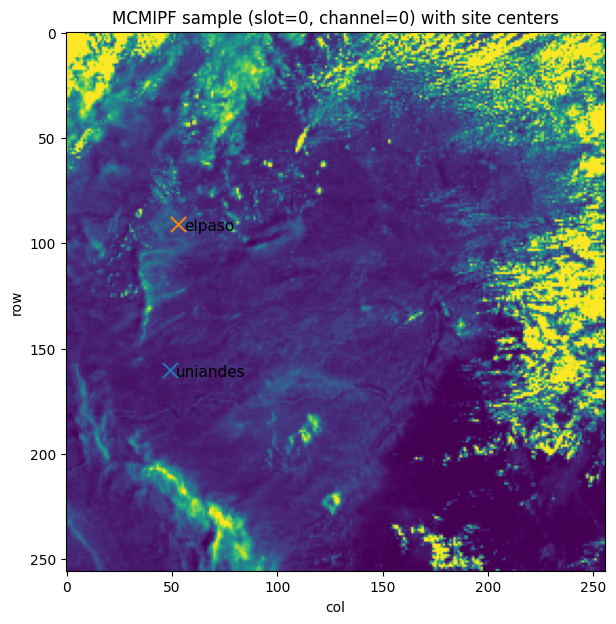

In [35]:
slot = 0
channel = 0
img = mcmipf[slot, channel]

plt.figure(figsize=(7, 7))
plt.imshow(img, origin="upper", vmin=np.percentile(img, 5), vmax=np.percentile(img, 95))
plt.title(f"MCMIPF sample (slot={slot}, channel={channel}) with site centers")
plt.xlabel("col")
plt.ylabel("row")

for site, (r, c) in site_center_pix.items():
    plt.scatter([c], [r], s=120, marker="x")
    plt.text(c + 3, r + 3, site, fontsize=11)

plt.show()

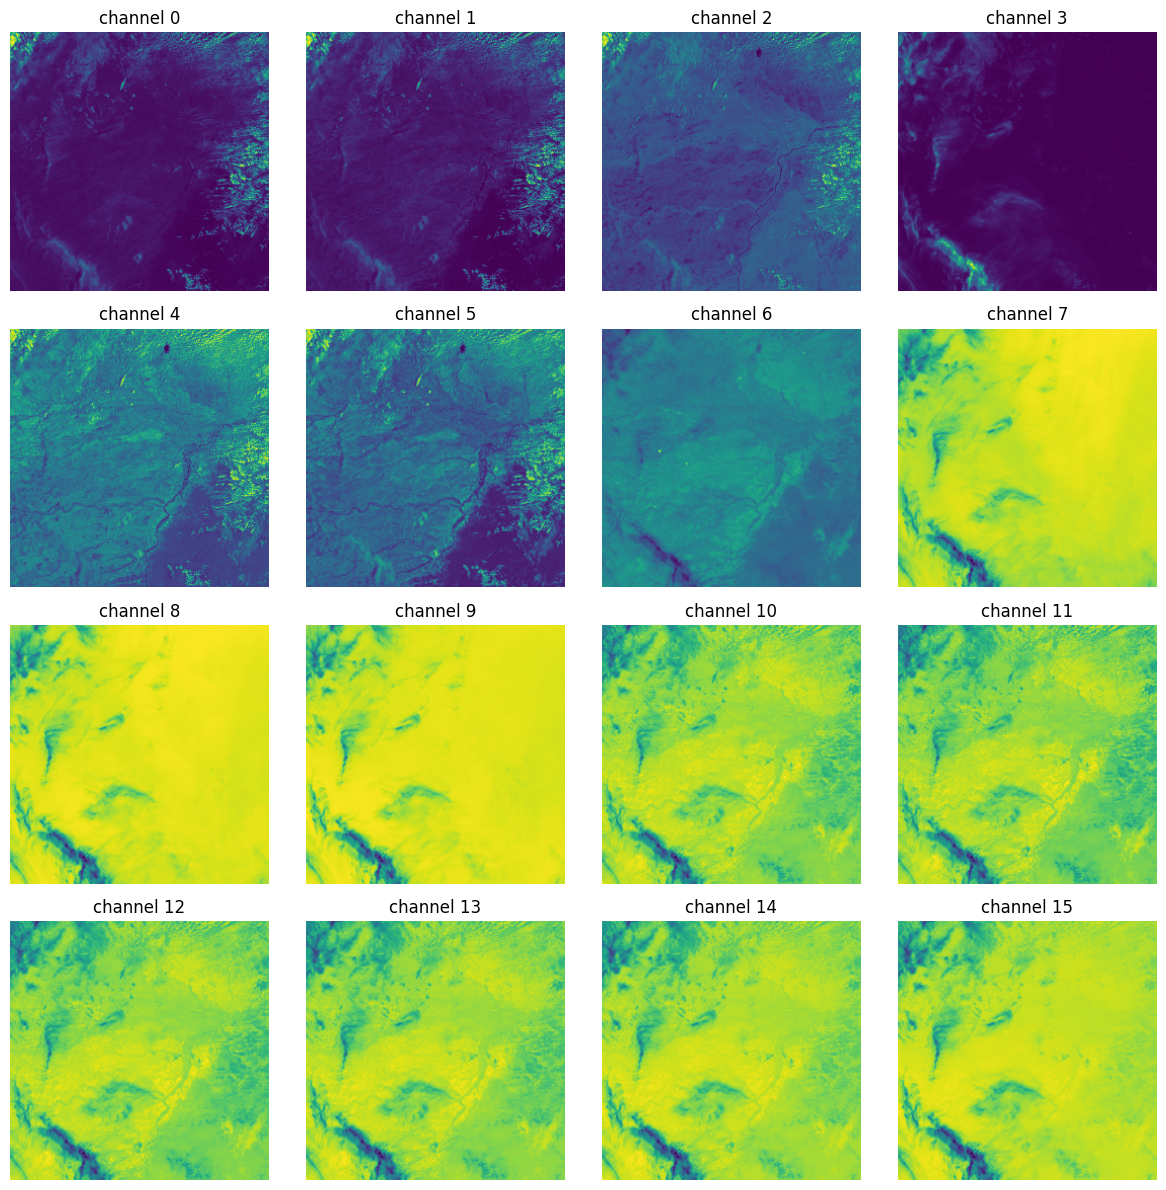

In [33]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for ch in range(16):
    img = mcmipf[0, ch]
    ax = axes[ch]
    ax.imshow(img, origin="upper")
    ax.set_title(f"channel {ch}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Export

In [34]:
OUT_DIR = PROJECT_ROOT / "data" / "metadata"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_json = OUT_DIR / "site_center_pix_256.json"

payload = {
    "grid_out": GRID_OUT,
    "crop_bounds_native": {"X0": X0, "X1": X1, "Y0": Y0, "Y1": Y1},
    "sites": {k: {"row": int(v[0]), "col": int(v[1])} for k, v in site_center_pix.items()},
    "notes": "Computed from one GOES NetCDF projection + documented crop bounds. Coordinates are on the processed 256x256 grid."
}

with open(out_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved:", out_json)
print(json.dumps(payload, indent=2))

Saved: /srv/projects/Proyecto_e_ladino/data/metadata/site_center_pix_256.json
{
  "grid_out": 256,
  "crop_bounds_native": {
    "X0": 2550,
    "X1": 3650,
    "Y0": 1800,
    "Y1": 2850
  },
  "sites": {
    "uniandes": {
      "row": 160,
      "col": 49
    },
    "elpaso": {
      "row": 91,
      "col": 53
    }
  },
  "notes": "Computed from one GOES NetCDF projection + documented crop bounds. Coordinates are on the processed 256x256 grid."
}
